# HR Analytics
## Analyzing Employee Turnover and Retention at NeoTech Corporation.

this notebook analyzes the employee turnover and retention patterns at NeoTech Corporations for the last two years. The aim is to identify potential causes behind the company's high turnover rate and develope retention stratagies based on isights drawn from the data.

## Data Gathering and Assesment

In [1]:
# importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# importing dataset
hr_df = pd.read_excel('/kaggle/input/neotech-hr-employee-data/HR_Employee_Data.xlsx')
hr_df.head()

,Emp_Id,satisfaction_level,last_evaluation,number_project,average_montly_hours,Commute_time,Work_accident,left,promotion_last_5years,Department,salary,Training_Last_Year
0,EMP02438,0.38,0.53,2,157,3,0,1,0,sales,low,0
1,EMP28133,0.80,0.86,5,262,6,0,1,0,sales,medium,0
2,EMP07164,0.11,0.88,7,272,4,0,1,0,sales,medium,0
3,EMP30478,0.72,0.87,5,223,5,0,1,0,sales,low,0
4,EMP24003,0.37,0.52,2,159,3,0,1,0,sales,low,0


In [3]:
#data assesment
hr_df.sample(10)

,Emp_Id,satisfaction_level,last_evaluation,number_project,average_montly_hours,Commute_time,Work_accident,left,promotion_last_5years,Department,salary,Training_Last_Year
201,EMP06625,0.39,0.50,2,135,3,0,1,0,support,low,0
7820,EMP14956,0.12,0.84,4,218,6,0,0,0,technical,medium,0
4227,EMP19300,0.67,0.67,3,183,3,0,0,0,accounting,medium,0
14819,EMP16242,0.45,0.49,2,134,3,0,1,0,RandD,medium,0
8845,EMP39388,0.73,0.84,4,238,2,0,0,0,product_mng,medium,0
13113,EMP44735,0.76,0.92,3,176,2,0,0,0,IT,medium,0
10118,EMP35952,0.13,0.72,4,154,4,0,0,0,technical,medium,0
1368,EMP15680,0.41,0.52,2,132,3,0,1,0,RandD,low,0
14850,EMP08923,0.43,0.48,2,153,3,0,1,0,accounting,low,0
297,EMP24340,0.40,0.52,2,147,3,0,1,0,product_mng,medium,0


In [4]:
hr_df.shape

(14999, 12)

In [5]:
hr_df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,Commute_time,Work_accident,left,promotion_last_5years,Training_Last_Year
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268,0.027202
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281,0.162676
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
hr_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Emp_Id                 14999 non-null  object 
 1   satisfaction_level     14999 non-null  float64
 2   last_evaluation        14999 non-null  float64
 3   number_project         14999 non-null  int64  
 4   average_montly_hours   14999 non-null  int64  
 5   Commute_time           14999 non-null  int64  
 6   Work_accident          14999 non-null  int64  
 7   left                   14999 non-null  int64  
 8   promotion_last_5years  14999 non-null  int64  
 9   Department             14999 non-null  object 
 10  salary                 14999 non-null  object 
 11  Training_Last_Year     14999 non-null  int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 1.4+ MB


In [7]:
# checking for null values
hr_df.isnull().sum()

Emp_Id                   0
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
Commute_time             0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
Training_Last_Year       0
dtype: int64

In [8]:
# checking for duplicates
hr_df.duplicated().sum()

0

In [9]:
# checking for unique values
hr_df.nunique()

Emp_Id                   14999
satisfaction_level          92
last_evaluation             65
number_project               6
average_montly_hours       215
Commute_time                 8
Work_accident                2
left                         2
promotion_last_5years        2
Department                  10
salary                       3
Training_Last_Year           2
dtype: int64

In [10]:
# counting values in the department column
hr_df.Department.value_counts()

Department
sales          4140
technical      2720
support        2229
IT             1227
product_mng     902
marketing       858
RandD           787
accounting      767
hr              739
management      630
Name: count, dtype: int64

In [11]:
# counting values in the salary column
hr_df.salary.value_counts()

salary
low       7316
medium    6446
high      1237
Name: count, dtype: int64

In [12]:
# creating a copy of the dataset
df = hr_df.copy()

## Exploratory Data Analysis
### Univariate Exploration

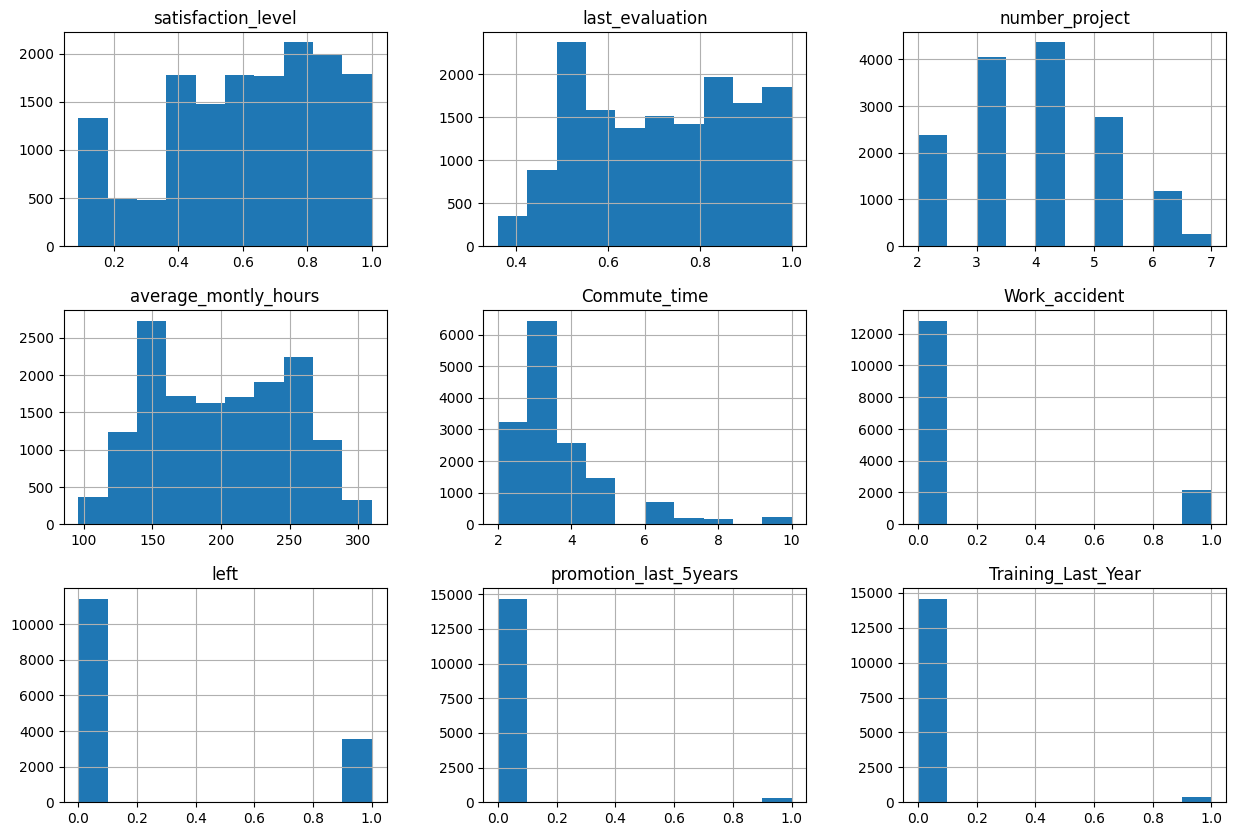

In [13]:
df.hist(figsize=(15,10));

#### How does satisfation level vary across the dataset?

In [14]:
df['satisfaction_level'].describe()

count    14999.000000
mean         0.612834
std          0.248631
min          0.090000
25%          0.440000
50%          0.640000
75%          0.820000
max          1.000000
Name: satisfaction_level, dtype: float64

#### Satisfaction score statistical summary
The dataset represents a range of eployee satisfaction levels, with most satisfaction scores falling between 44% and 82%. The average satisfaction score is 61.3%, indicate a moderate level of satisfaction.

The scores have a moderate spread, with standard diviation of approximately 0.249.

The lowest satisfaction score is 9% (0.09) and the highest is 100% (1.0).

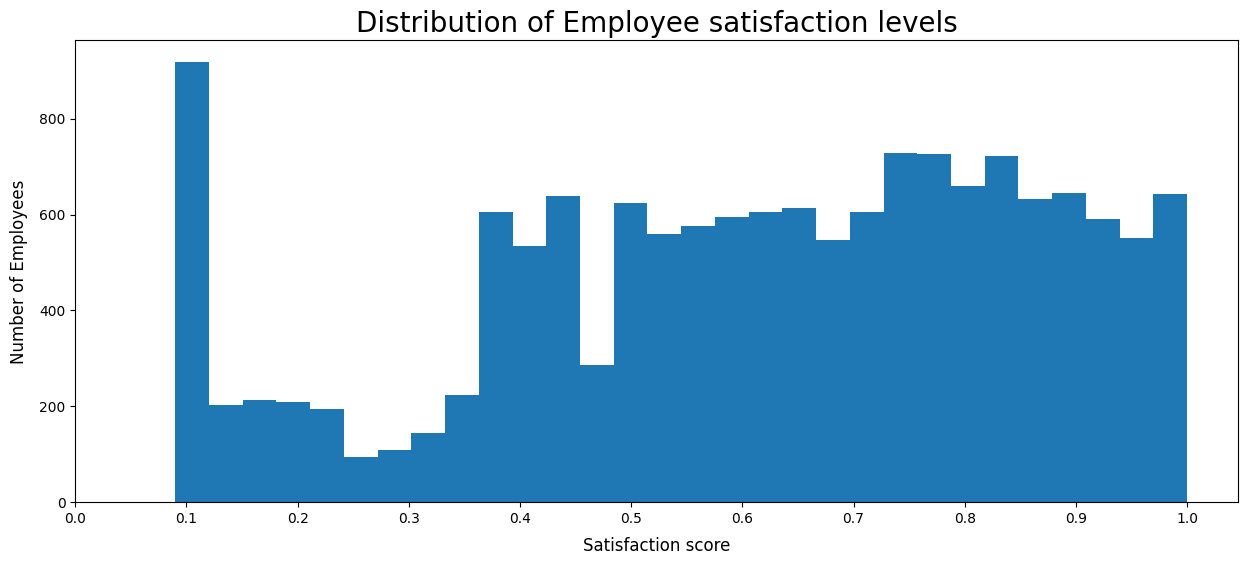

In [15]:
# plotting a histogram of satisfaction level
plt.figure(figsize=[15,6]) # setting image size
bins = 30

plt.hist(x=df.satisfaction_level, bins=bins)

# set the x axis ticks to be from 0.1 to 1 with a specified number of ticks (10 ticks)
tick_values = np.arange(0, 1.1, 0.1)
plt.xticks(tick_values)

plt.title('Distribution of Employee satisfaction levels', fontsize=20)
plt.xlabel('Satisfaction score', labelpad=8, fontsize=12)
plt.ylabel('Number of Employees', labelpad=8, fontsize=12)

plt.show()

The shape of the histogram is multimodal, having more than two peaks. This suggests that there are multiple distinct groups or patterns within satisfaction levels among employees. this could be indicative of different experiences or conditions within the organisation that affect employee satisfaction.

The histogram shows over 800 employees with satisfaction score of less than 15%. This large group of highly dissatified employees might indicate systemic issues or specific areas of the organisation that are underperfoming in terms of employee satisfaction.

The peack around 40% representing a group with satisfaction scores between 35% and 45%, suggest a distict category of employees. his group is not as dissatified as the first one but not full satisfied either.


#### How does employees last performance evaluation vary across the dataset?

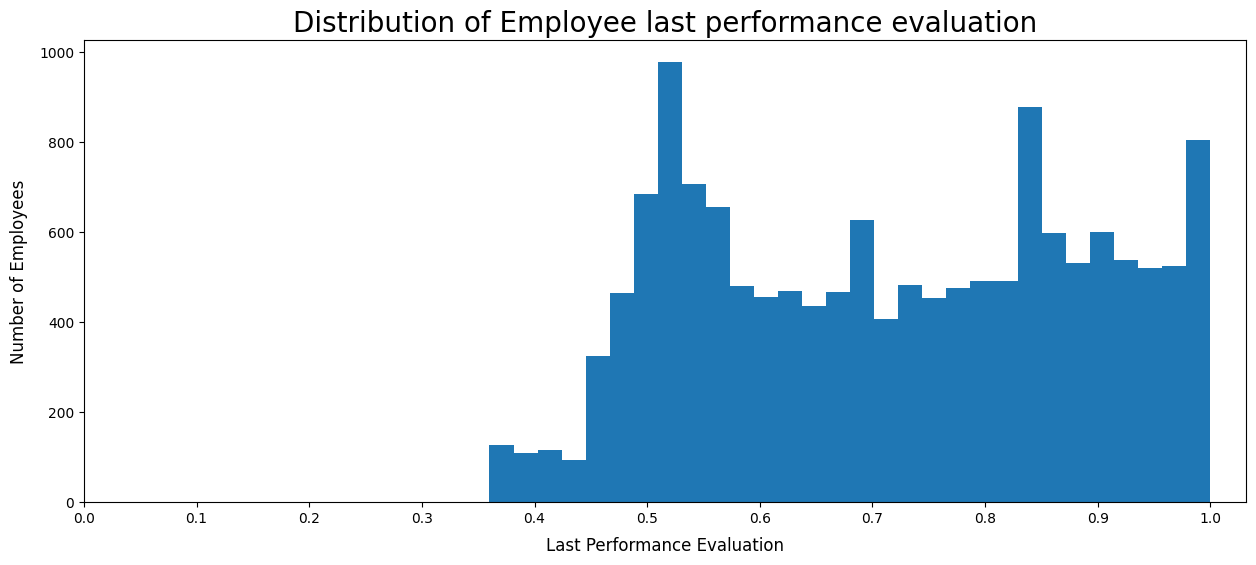

In [16]:
# plotting a histogram of employee last performance evaluation
plt.figure(figsize=[15,6]) # setting image size
bins = 30

plt.hist(x=df.last_evaluation, bins=bins)

# set the x axis ticks to be from 0.1 to 1 with a specified number of ticks (10 ticks)
tick_values = np.arange(0, 1.1, 0.1)
plt.xticks(tick_values)

plt.title('Distribution of Employee last performance evaluation', fontsize=20)
plt.xlabel('Last Performance Evaluation', labelpad=8, fontsize=12)
plt.ylabel('Number of Employees', labelpad=8, fontsize=12)

plt.show()

In [17]:
df['last_evaluation'].describe()

count    14999.000000
mean         0.716102
std          0.171169
min          0.360000
25%          0.560000
50%          0.720000
75%          0.870000
max          1.000000
Name: last_evaluation, dtype: float64

The Evaluations are fairly evenly distributed with a slight skew towards higher ratings. A large population of employees have performance evaluations between 50% and 100% with peak around 50% and 87%.


#### How does the average monthly hours vary across the dataset?

In [18]:
df['average_montly_hours'].describe()

count    14999.000000
mean       201.050337
std         49.943099
min         96.000000
25%        156.000000
50%        200.000000
75%        245.000000
max        310.000000
Name: average_montly_hours, dtype: float64

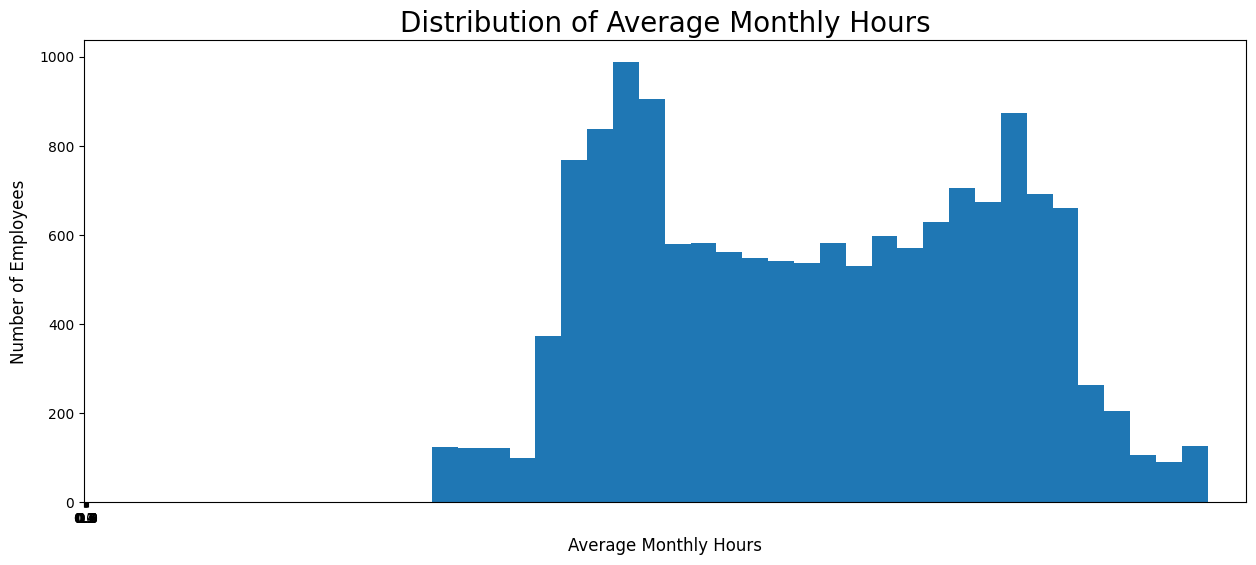

In [19]:
# plotting a histogram of average monthly hours
plt.figure(figsize=[15,6]) # setting image size
bins = 30

plt.hist(x=df.average_montly_hours, bins=bins)

# set the x axis ticks to be from 0.1 to 1 with a specified number of ticks (10 ticks)
tick_values = np.arange(0, 1.1, 0.1)
plt.xticks(tick_values)

plt.title('Distribution of Average Monthly Hours', fontsize=20)
plt.xlabel('Average Monthly Hours', labelpad=8, fontsize=12)
plt.ylabel('Number of Employees', labelpad=8, fontsize=12)

plt.show()

There are two peaks observed. one peak lie in the range of 150 to 200 hours, and the other peak is in the 250 to 300 hours range. This suggest that there are two distinct group of employees based on their working hours.


#### How does Commute Time vary across the dataset?

In [20]:
df['Commute_time'].describe()

count    14999.000000
mean         3.498233
std          1.460136
min          2.000000
25%          3.000000
50%          3.000000
75%          4.000000
max         10.000000
Name: Commute_time, dtype: float64

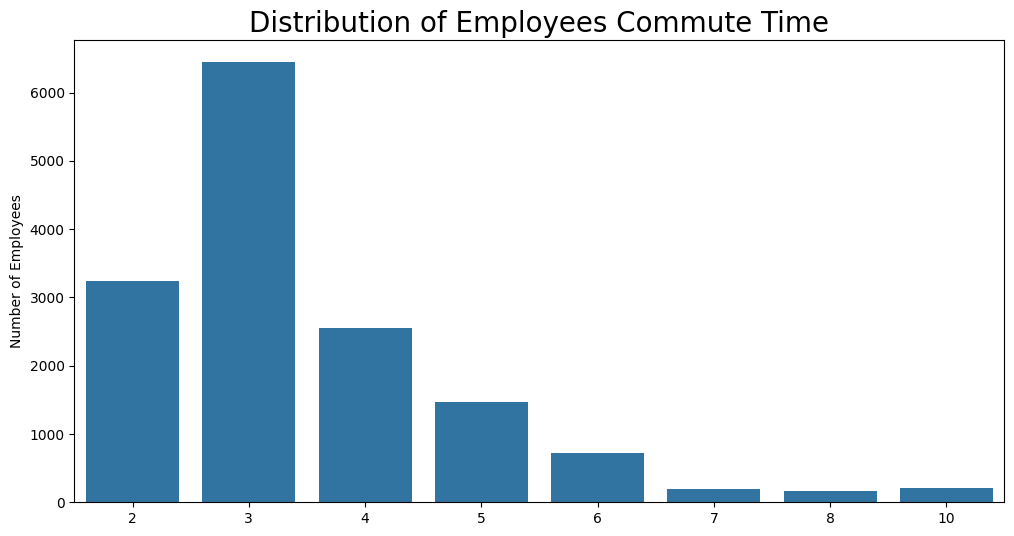

In [21]:
# setting default palette color 
default_color = sns.color_palette()[0]

plt.figure(figsize=[12,6])
sns.countplot(x=df.Commute_time, color=default_color)

plt.title('Distribution of Employees Commute Time', fontsize=20)
plt.xlabel('')
plt.ylabel('Number of Employees')

plt.show()

The data is skewed to the right. Quite a number of employees spend 6 to 10 hours commuting to work which is alot to travel.


#### What is the distribution of Employees across each department? ####

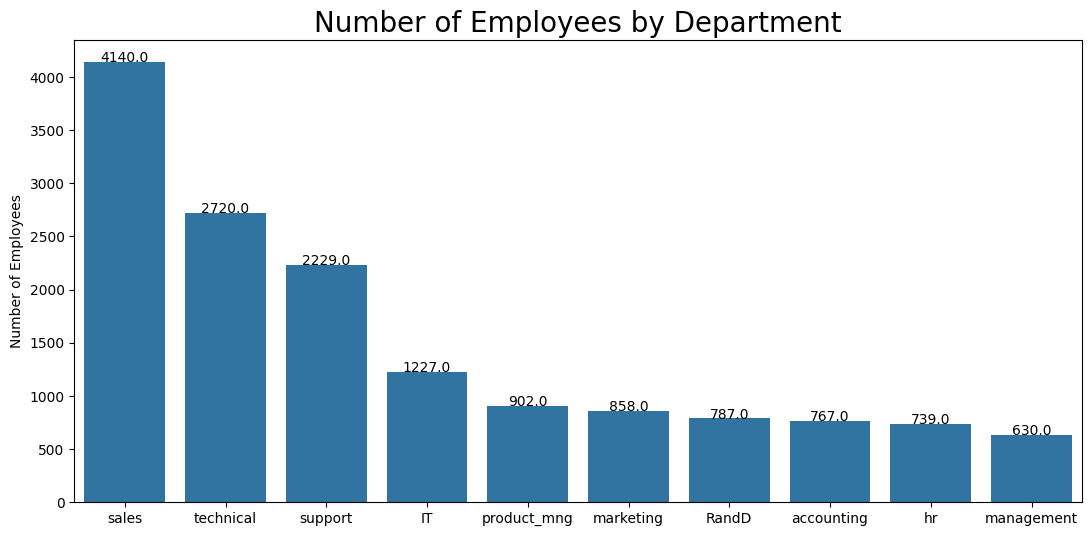

In [22]:
plt.figure(figsize=[13,6])
ax = sns.countplot(x=df.Department, color=default_color, order=df['Department'].value_counts().index)

# Adding data label counts to the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}',(p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline')
    
    plt.title('Number of Employees by Department', fontsize=20)
plt.xlabel('')
plt.ylabel('Number of Employees')

plt.show()

The Sales Team have the highest number of Employees while the Management Team have the least.


#### What is the Distribution of Employee Salary 

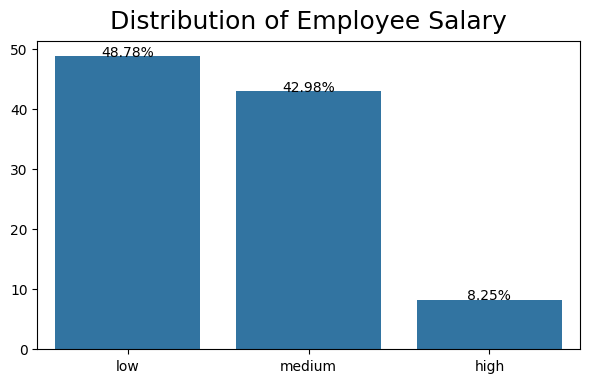

In [23]:
plt.figure(figsize=[7, 4])

# Calculating the percentage distribution of salaries
salary_percentages = (df['salary'].value_counts() / len(df)) * 100

# Plotting the bar plot
ax = sns.barplot(x=salary_percentages.index, y=salary_percentages.values, color=default_color, order=salary_percentages.index)

# Adding data label counts to the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline')

plt.title('Distribution of Employee Salary', fontsize=18, y=1.015)
plt.xlabel('')
plt.ylabel('')

plt.show()

Only 8.25% of employees earn high salaries and 42.9% earn medium salaries.

#### What is the Distribution of Employees that got promoted in the last 5 years?

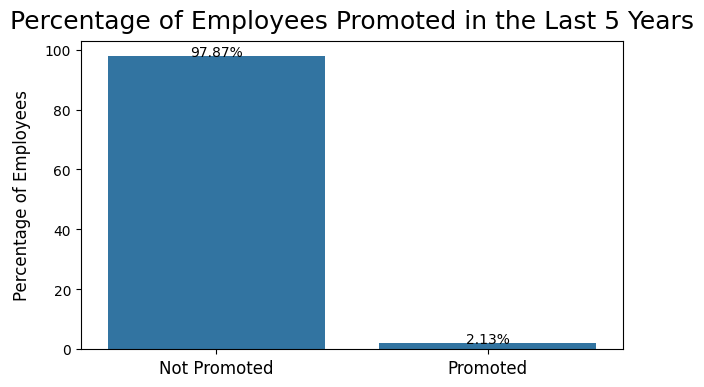

In [24]:
plt.figure(figsize=[7, 4])

# Calculating the percentage distribution of promotions in the last 5 years
promotion_percentages = (df['promotion_last_5years'].value_counts() / len(df)) * 100

# Plotting the bar plot
ax = sns.barplot(x=promotion_percentages.index, y=promotion_percentages.values, color=default_color, order=[0, 1])

# Adding labels to the x-axis
plt.xticks(ticks=[0, 1], labels=['Not Promoted', 'Promoted'], fontsize=12)

# Adding title and labels
plt.title('Percentage of Employees Promoted in the Last 5 Years', fontsize=18, y=1.015)
plt.xlabel('')
plt.ylabel('Percentage of Employees', labelpad=10, fontsize=12)

# Adding data labels to the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline')

# Display the plot
plt.show()

Only 2% of employees were promoted in the last 5 years which is very low and indicates that there is little room for career growth within the company.


#### What percentage of Trained Employees left the company in the last 2 years? ####

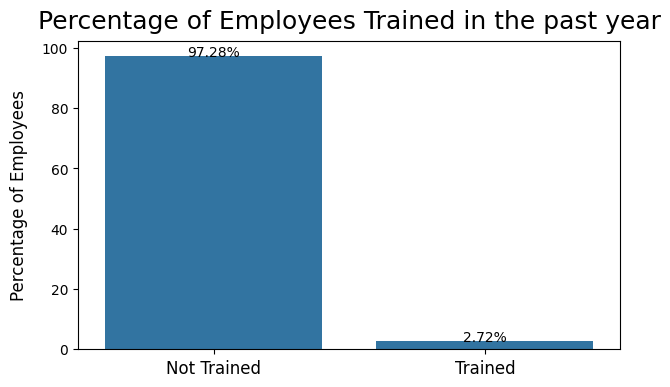

In [25]:
plt.figure(figsize=[7, 4])

# Calculating the percentage distribution of promotions in the last 5 years
trained_percentages = (df['Training_Last_Year'].value_counts() / len(df)) * 100

# Plotting the bar plot
ax = sns.barplot(x=trained_percentages.index, y=trained_percentages.values, color=default_color, order=[0, 1])

# Adding labels to the x-axis
plt.xticks(ticks=[0, 1], labels=['Not Trained', 'Trained'], fontsize=12)

# Adding title and labels
plt.title('Percentage of Employees Trained in the past year', fontsize=18, y=1.015)
plt.xlabel('')
plt.ylabel('Percentage of Employees', labelpad=10, fontsize=12)

# Adding data labels to the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline')

# Display the plot
plt.show()

Only 2.7% of employees were trained in the past year.


#### What Percentage of Employees were involved in a work accident? ####

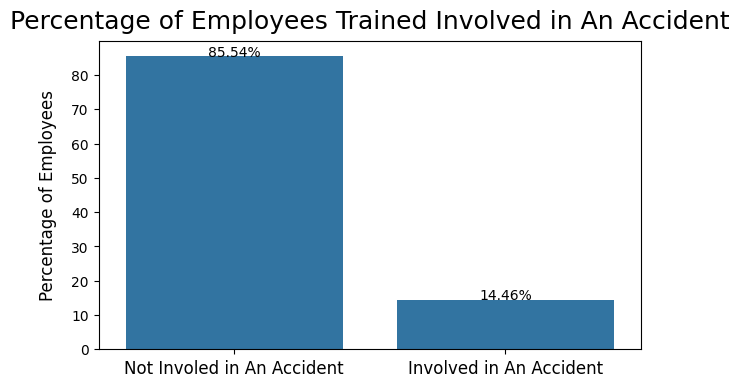

In [26]:
plt.figure(figsize=[7, 4])

# Calculating the percentage distribution of promotions in the last 5 years
work_accient_percentages = (df['Work_accident'].value_counts() / len(df)) * 100

# Plotting the bar plot
ax = sns.barplot(x=work_accient_percentages.index, y=work_accient_percentages.values, color=default_color, order=[0, 1])

# Adding labels to the x-axis
plt.xticks(ticks=[0, 1], labels=['Not Involed in An Accident', 'Involved in An Accident'], fontsize=12)

# Adding title and labels
plt.title('Percentage of Employees Trained Involved in An Accident', fontsize=18, y=1.015)
plt.xlabel('')
plt.ylabel('Percentage of Employees', labelpad=10, fontsize=12)

# Adding data labels to the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline')

# Display the plot
plt.show()

Approximately 14.46% of the work force were involved in an accident during their tenure.


#### What is The Percentage of Employee Turnover in the Last 2 years ####

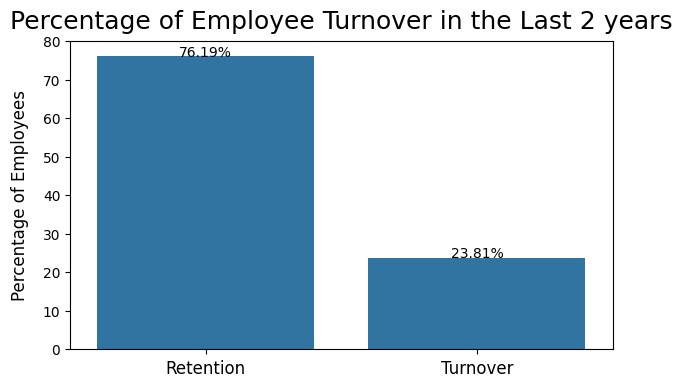

In [27]:
plt.figure(figsize=[7, 4])

# Calculating the percentage of employee turnover
left_percentage = (df['left'].value_counts() / len(df)) * 100

# Plotting the bar plot
ax = sns.barplot(x=left_percentage.index, y=left_percentage.values, color=default_color, order=[0, 1])

# Adding labels to the x-axis
plt.xticks(ticks=[0, 1], labels=['Retention', 'Turnover'], fontsize=12)

# Adding title and labels
plt.title('Percentage of Employee Turnover in the Last 2 years', fontsize=18, y=1.015)
plt.xlabel('')
plt.ylabel('Percentage of Employees', labelpad=10, fontsize=12)

# Adding data labels to the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline')

# Display the plot
plt.show()

Approximately 23.8% of the work force left the company.


### Bivariate Exploration

Identifying the factors that influences employee retention the most. The target variable is the left variable and the independent variables are satisfaction_level, last_evaluation, number_project, average_monthly_hours, promotion_last_5years etc.

Examining how each variable relates to the target variable which is whether or not an employee left the company. This will be done by answering the following questions.

1. Which Departent have the highest number of employes leaving the company?
2. Do employees with higher salaries tend to stay longer? Is there any relationship between salary and employee retention?
3. Is there a correlation between employee satisfaction levels and their retention within the organisation?
4. How do performance evaluation scores differ between employees who leave and those who stay?
5. Do employees who work on more project have higher turnover rate?
6. Do employees who work longer hours have higher turnover rate?
7. How does commute time affect employee retention?
8. Do work accidents lead to employees leaving the company?
9. Are employees who are promoted more or less likely to stay in the company?
10. How many employees who were trained in the past year decided to stay in the company?


#### Which Department have the highest employee turnover and retention rate?

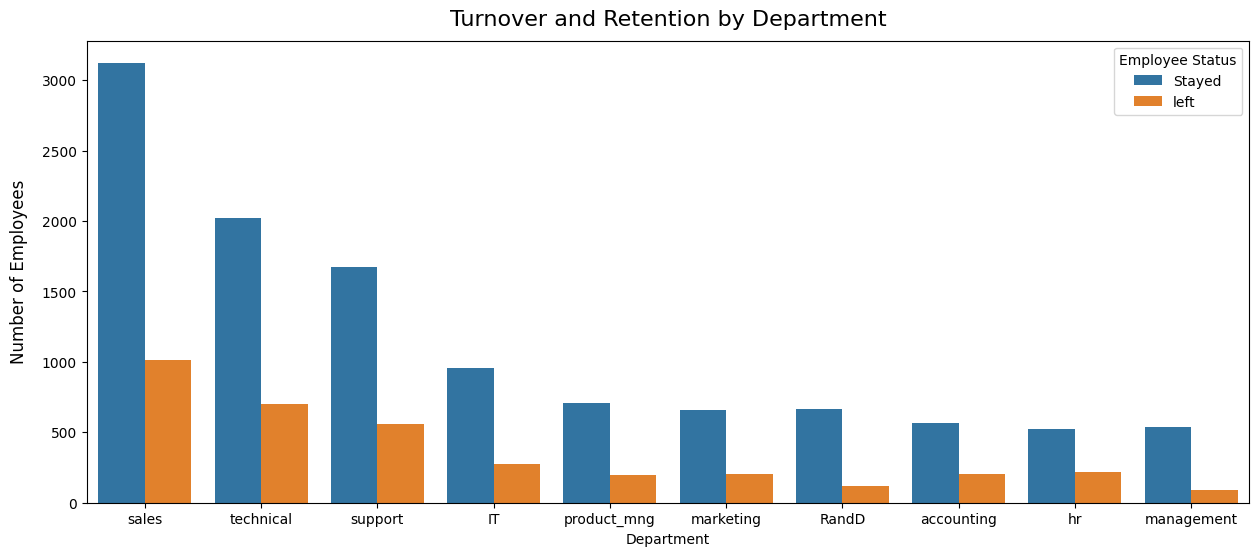

In [28]:
plt.figure(figsize=[15,6])
sns.countplot(data=df, x=df['Department'], hue='left', order=df['Department'].value_counts().index)
plt.title('Turnover and Retention by Department', fontsize=16, y=1.015)
plt.legend(title='Employee Status', labels=['Stayed', 'left'])
plt.ylabel('Number of Employees', labelpad=10, fontsize=12)

plt.show();

Sales, Technical and Support has the highest number of employees leaving the company. Management has the least number of employees leaving the company.

#### Do employees with higher salaries tend to stay longer? Is there any relationship between salary and employee retention?

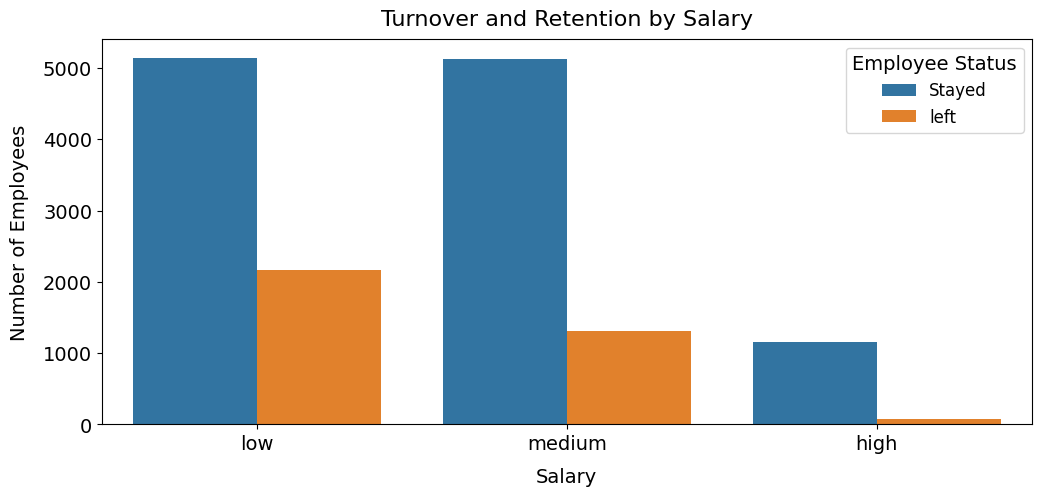

In [29]:
plt.figure(figsize=[12,5])
ax = sns.countplot(data=df, x=df['salary'], hue='left', order=df['salary'].value_counts().index)
plt.title('Turnover and Retention by Salary', fontsize=16, y=1.015)
plt.xlabel('Salary', labelpad=10, fontsize=14)
plt.ylabel('Number of Employees', labelpad=10, fontsize=14)

# setting label size
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
plt.legend(title='Employee Status', labels=['Stayed', 'left'], fontsize=12, title_fontsize=14)

plt.show();

#### Is there a correlation between employee satisfaction levels and their retention within the organisation?

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


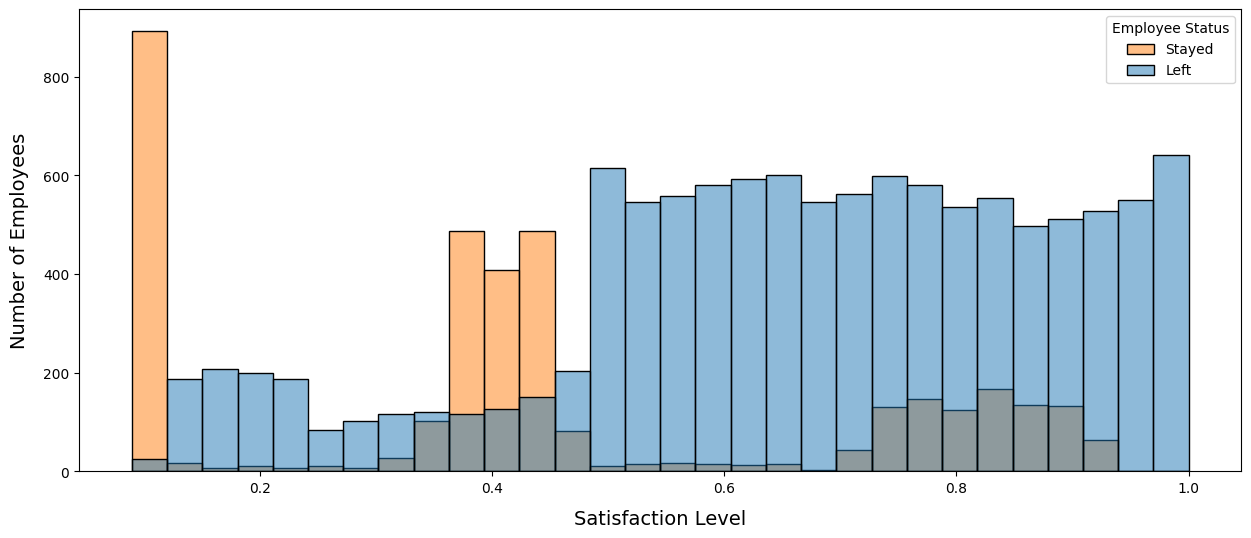

In [30]:
plt.figure(figsize=[15, 6])

# Using sns.histplot to create the histogram
sns.histplot(data=df, x='satisfaction_level', hue='left')

# Adding labels to the axes
plt.xlabel('Satisfaction Level', labelpad=10, fontsize=14)
plt.ylabel('Number of Employees', labelpad=10, fontsize=14)

# Adjusting the legend
plt.legend(title='Employee Status', labels=['Stayed', 'Left'])

# Displaying the plot
plt.show();

There is a notable cluster of employees who left the company at the lower end of the satisfaction scale, indicating that lower stisfaction levels are associated with higher turnover.

Employees who satyed with the company tends to have a wider distribution of satisfaction levels but a concentration towards the higher end of the scale.

There is also a small peak of employees who left at high satis faction levels which might suggest thatsome other factors beyond satisfaction are influencing their decision to leave.

Segmenting the satisfaction scores into groups to properly visualize the trend.
1. Very Dissatisfied: 1%-25%
2. Dissatisfied: 25%-50%
3. Neutral: 51%-60%
4. Satisfied: 61%-80%
5. Very Satisfied: 81%-100%

In [31]:
# defining the bins for satisfaction level
bins = [0, 0.25, 0.50, 0.60, 0.80, 1.0]
labels = ['Very Dissatisfied', 'Dissatisfied', 'Neutral', 'Satisfied', 'Very Satisfied']

# creating a new column 'Satisfaction Level' by cutting the satisfaction level into bins
df['Satisfaction Level'] = pd.cut(df['satisfaction_level'], bins=bins, labels=labels, include_lowest=True)
 
df.head()

,Emp_Id,satisfaction_level,last_evaluation,number_project,average_montly_hours,Commute_time,Work_accident,left,promotion_last_5years,Department,salary,Training_Last_Year,Satisfaction Level
0,EMP02438,0.38,0.53,2,157,3,0,1,0,sales,low,0,Dissatisfied
1,EMP28133,0.80,0.86,5,262,6,0,1,0,sales,medium,0,Satisfied
2,EMP07164,0.11,0.88,7,272,4,0,1,0,sales,medium,0,Very Dissatisfied
3,EMP30478,0.72,0.87,5,223,5,0,1,0,sales,low,0,Satisfied
4,EMP24003,0.37,0.52,2,159,3,0,1,0,sales,low,0,Dissatisfied


/opt/conda/lib/python3.10/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/opt/conda/lib/python3.10/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


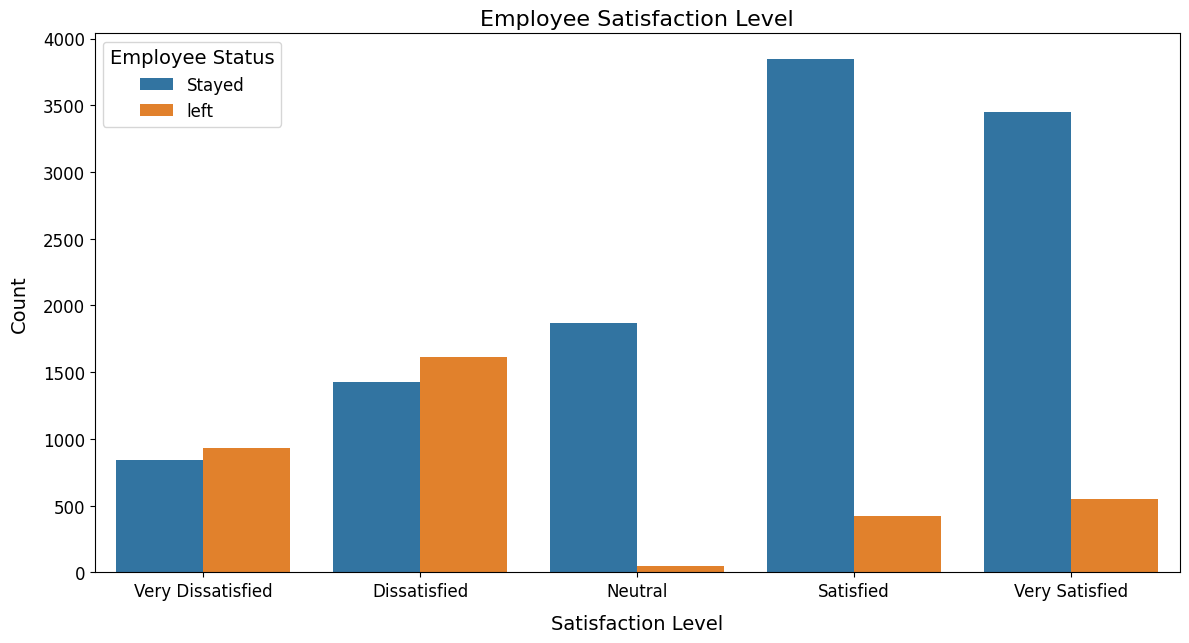

In [32]:
# visualizing the result using a count plot 'left' as hue
plt.figure(figsize=[14,7])
ax = sns.countplot(data=df, x=df['Satisfaction Level'], hue='left')
plt.title('Employee Satisfaction Level', fontsize=16)
plt.xlabel('Satisfaction Level', labelpad=10, fontsize=14)
plt.ylabel('Count', labelpad=10, fontsize=14)

# setting label size
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
plt.legend(title='Employee Status', labels=['Stayed', 'left'], fontsize=12, title_fontsize=14)

plt.show();

There is a stanadrd number of employee turnover in the **Very Dissatisfied** and **Dissatisfied** categories, suggesting a strong link between low satisfaction levels and high turnover.

The **Neutral** category shows a smaller, yet significant number of employees leaving which could imply that even a lack of strong positive or negative feelings can be associated with turnover.

The **Satisfied** and **Very Satisfied** categories have a larger number of employees who stayed which supports the idea that higher satisfaction correlaes with rention. However, there are still employees who left the company despite being in the **Satisfied** and **Very Satisfied** categories indicating that satisfaction is not the sole factor in an employee's decision to stay or leave.

In [33]:
df[df['satisfaction_level']<=0.5]

,Emp_Id,satisfaction_level,last_evaluation,number_project,average_montly_hours,Commute_time,Work_accident,left,promotion_last_5years,Department,salary,Training_Last_Year,Satisfaction Level
0,EMP02438,0.38,0.53,2,157,3,0,1,0,sales,low,0,Dissatisfied
2,EMP07164,0.11,0.88,7,272,4,0,1,0,sales,medium,0,Very Dissatisfied
4,EMP24003,0.37,0.52,2,159,3,0,1,0,sales,low,0,Dissatisfied
5,EMP08609,0.41,0.50,2,153,3,0,1,0,sales,low,0,Dissatisfied
6,EMP14345,0.10,0.77,6,247,4,0,1,0,sales,low,0,Very Dissatisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14994,EMP40221,0.40,0.57,2,151,3,0,1,0,support,low,0,Dissatisfied
14995,EMP24196,0.37,0.48,2,160,3,0,1,0,support,low,0,Dissatisfied
14996,EMP33544,0.37,0.53,2,143,3,0,1,0,support,low,0,Dissatisfied
14997,EMP40533,0.11,0.96,6,280,4,0,1,0,support,low,0,Very Dissatisfied


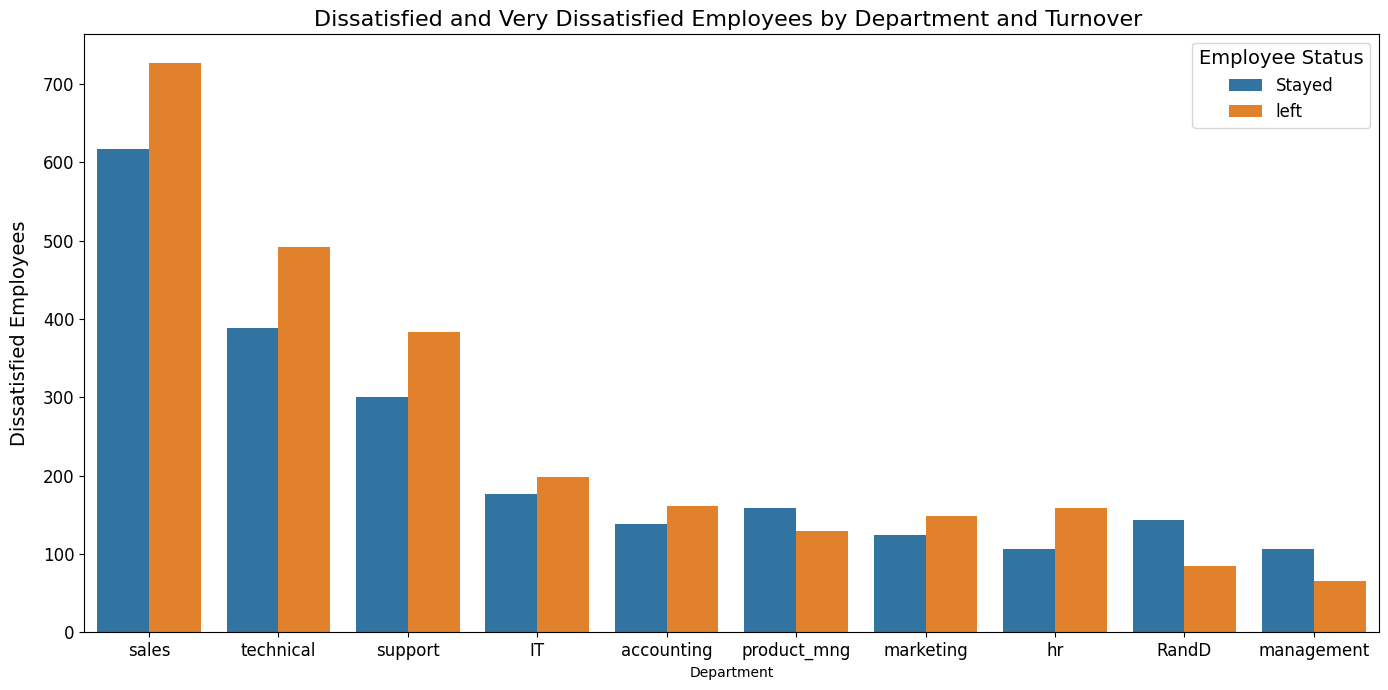

In [34]:
# selecting dissatisfied employees 
dissatisfied_employees = df[df['satisfaction_level']<=0.5]

# visualizing the count of dissatisfied employees with 'left' as hue
plt.figure(figsize=[14,7])
ax = sns.countplot(data=dissatisfied_employees, x='Department', hue='left', order=dissatisfied_employees['Department'].value_counts().index)
plt.title('Dissatisfied and Very Dissatisfied Employees by Department and Turnover ', fontsize=16)
plt.ylabel('Dissatisfied Employees', labelpad=10, fontsize=14)

# setting label size
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
plt.legend(title='Employee Status', labels=['Stayed', 'left'], fontsize=12, title_fontsize=14)
plt.tight_layout()

plt.show();

The Sales, Technical and Support Department are the top 3 departments with the most number of Dissatisfied employees and more than half of these employees have left the company.


#### How do performance evaluation scores differ between employees who leave and those who stay?

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


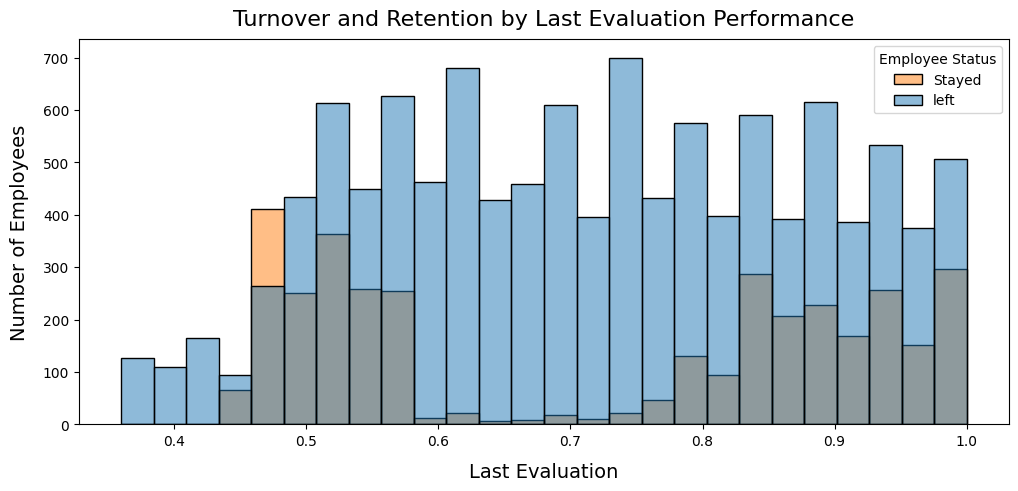

In [35]:
plt.figure(figsize=[12,5])
sns.histplot(data=df, x='last_evaluation', hue='left')
plt.title('Turnover and Retention by Last Evaluation Performance', fontsize=16, y=1.015)
plt.xlabel('Last Evaluation', labelpad=10, fontsize=14)
plt.ylabel('Number of Employees', labelpad=10, fontsize=14)
plt.legend(title='Employee Status', labels=['Stayed', 'left'])

plt.show()

**From the histogram we can observe**
1. A Bimodal distribution for employees who left with peaks around scores 0.45 and 0.9. This suggest that both low and high performing employees are leaving the company.
2. There is a significant number of employees who left the company with high evaluation scores, which could indicate that even high performing employees are at risk of turnover.


#### Do employees who work on more project have higher turnover rate?

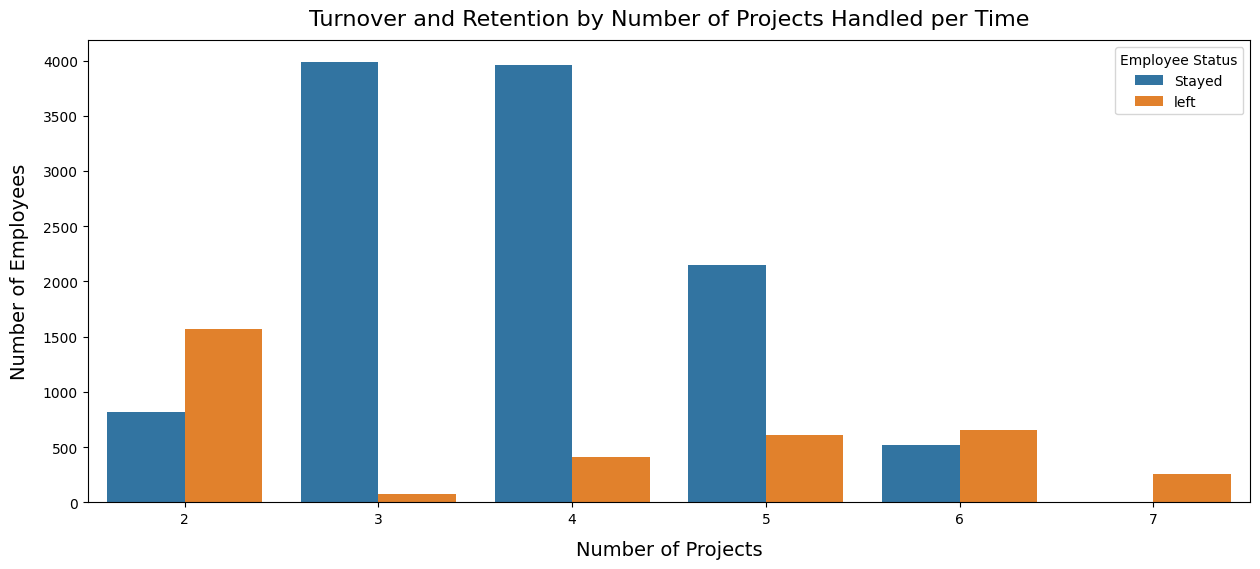

In [36]:
plt.figure(figsize=[15,6])
sns.countplot(data=df, x='number_project', hue='left')
plt.title('Turnover and Retention by Number of Projects Handled per Time', fontsize=16, y=1.015)
plt.xlabel('Number of Projects', labelpad=10, fontsize=14)
plt.ylabel('Number of Employees', labelpad=10, fontsize=14)
plt.legend(title='Employee Status', labels=['Stayed', 'left'])

plt.show()

* Employees who have handled 3 projects have the highest retenition rate and the lowest turnover rate compared to those with higher or lower number of projects.
* There is a high turnover rate among employees who have handled 6 or 7 projects which implies that higher workload or over commitment might be linked to burnout or subsequent turnover
*  Employees with at most 2 project also have high tendency to leave which might suggest that underutiliztion or lack of engegement my be a factor that in their decision to leave
* Those who have handled 3 to 5 projects have a mixed turnover and retention pattern, suggesting that there might be a sweet spot in terms of project load that balances employee engagement without leading  to burnout.


#### Do employees who work longer hours have higher turnover rate?

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

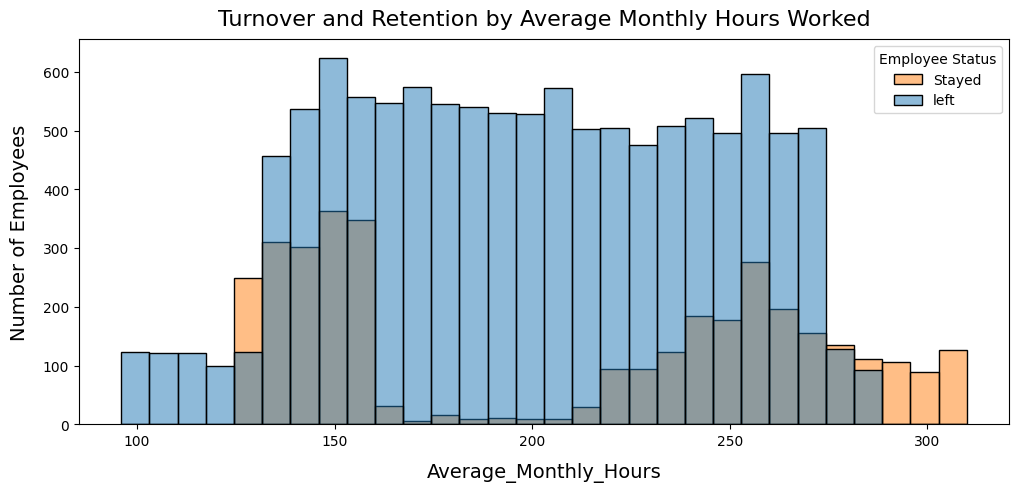

In [37]:
plt.figure(figsize=[12,5])
sns.histplot(data=df, x='average_montly_hours', hue='left')
plt.title('Turnover and Retention by Average Monthly Hours Worked', fontsize=16, y=1.015)
plt.xlabel('Average_Monthly_Hours', labelpad=10, fontsize=14)
plt.ylabel('Number of Employees', labelpad=10, fontsize=14)
plt.legend(title='Employee Status', labels=['Stayed', 'left'])

plt.show()

* There are 2 notable peaks for employees who left the company: onne of those working fewer hours (less than 160hrs) possibly indicating underemplyment or distribution with per time work and one of those working longer hours (greater than 200hrs) which indicates that employees who workovertime or long hours are at high risk of leaving possibly due to burnout, stress or insufficient work-life balance.
* Empolyees who stay with the company tend to have a more normally distributed pattern of average hours, peaking around the median average work hours which suggest that employees with balanced work hours are more likely to stay.


#### How does commute time affect employee retention?

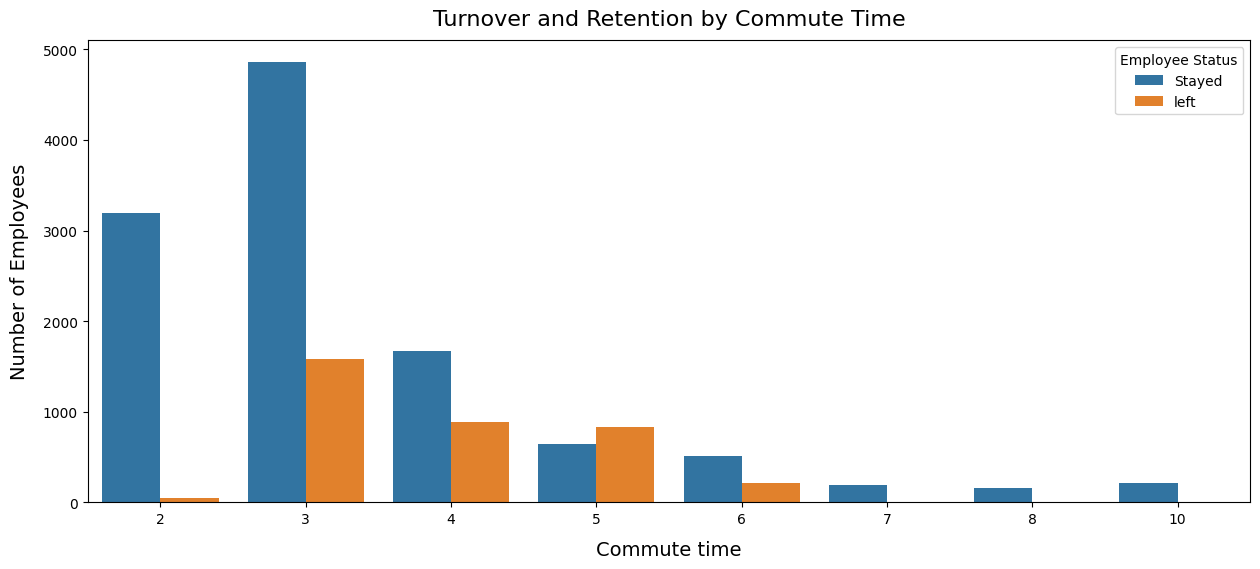

In [38]:
plt.figure(figsize=[15,6])
sns.countplot(data=df, x='Commute_time', hue='left')
plt.title('Turnover and Retention by Commute Time', fontsize=16, y=1.015)
plt.xlabel('Commute time', labelpad=10, fontsize=14)
plt.ylabel('Number of Employees', labelpad=10, fontsize=14)
plt.legend(title='Employee Status', labels=['Stayed', 'left'])

plt.show()

**From the visualzation we can observe**

* Employees with shorter commute time (2hrs) tend to stay in the company. As the commute time increases, there appear to be an increase in the number of employees who left the company. This may indicate that as the commute time becomes more burdensome, it may contribute to an employee's decision to leave.
* surprisinly employees who spend 7 to 10 hours on transit have stayed with the company

In [39]:
# selecting employees with longer commute time
df[df['Commute_time']>=7]

,Emp_Id,satisfaction_level,last_evaluation,number_project,average_montly_hours,Commute_time,Work_accident,left,promotion_last_5years,Department,salary,Training_Last_Year,Satisfaction Level
11007,EMP13636,0.49,0.67,2,190,8,0,0,0,marketing,medium,0,Dissatisfied
11008,EMP07335,0.92,0.99,3,176,8,0,0,0,sales,medium,0,Very Satisfied
11009,EMP42125,0.81,0.55,4,217,8,0,0,0,accounting,medium,0,Very Satisfied
11010,EMP20847,0.62,0.91,3,269,8,0,0,0,support,medium,0,Satisfied
11011,EMP08357,0.21,0.70,3,238,8,0,0,0,technical,medium,0,Very Dissatisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14205,EMP22493,0.22,0.94,3,193,10,0,0,1,management,high,1,Very Dissatisfied
14206,EMP34601,0.90,0.55,3,259,10,1,0,1,management,high,1,Very Satisfied
14207,EMP20672,0.74,0.95,5,266,10,0,0,1,management,high,1,Satisfied
14208,EMP23944,0.85,0.54,3,185,10,0,0,1,management,high,1,Very Satisfied


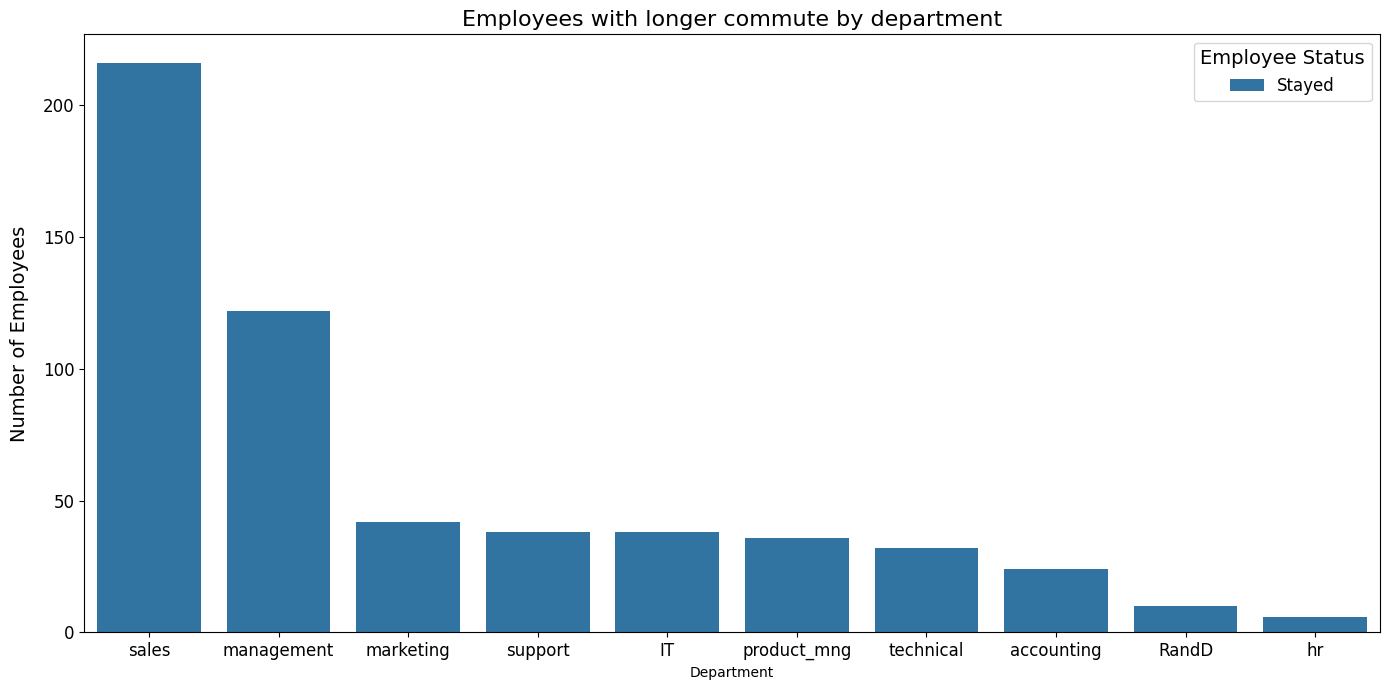

In [40]:
longer_commute = df[df['Commute_time']>=7]

# visualizing this employees by department with left as hue
plt.figure(figsize=[14,7])
ax = sns.countplot(data=longer_commute, x='Department', hue='left', order=longer_commute['Department'].value_counts().index)
plt.title('Employees with longer commute by department', fontsize=16)
plt.ylabel('Number of Employees', labelpad=10, fontsize=14)

# setting label size
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
plt.legend(title='Employee Status', labels=['Stayed', 'left'], fontsize=12, title_fontsize=14)
plt.tight_layout()

plt.show();

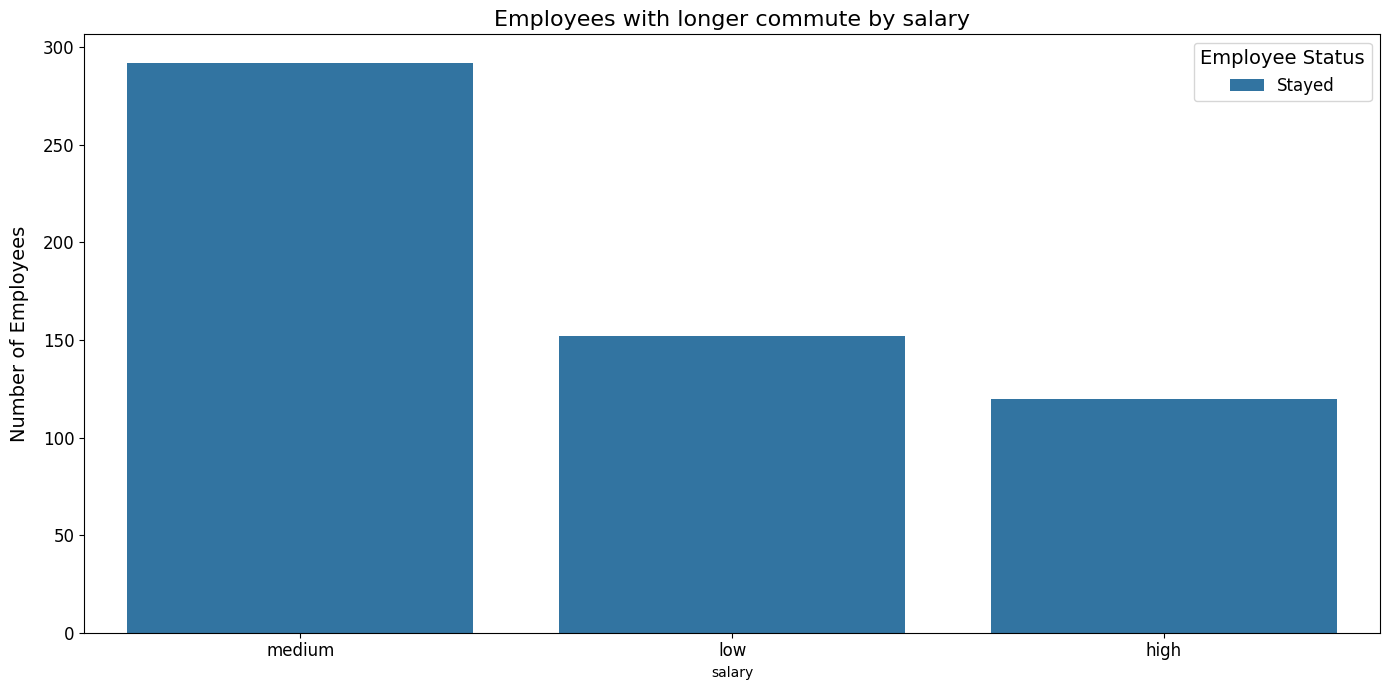

In [41]:
# visualizing this employees by department with left as hue
plt.figure(figsize=[14,7])
ax = sns.countplot(data=longer_commute, x='salary', hue='left', order=longer_commute['salary'].value_counts().index)
plt.title('Employees with longer commute by salary', fontsize=16)
plt.ylabel('Number of Employees', labelpad=10, fontsize=14)

# setting label size
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
plt.legend(title='Employee Status', labels=['Stayed', 'left'], fontsize=12, title_fontsize=14)
plt.tight_layout()

plt.show();

#### Do work accidents lead to employees leaving the company?

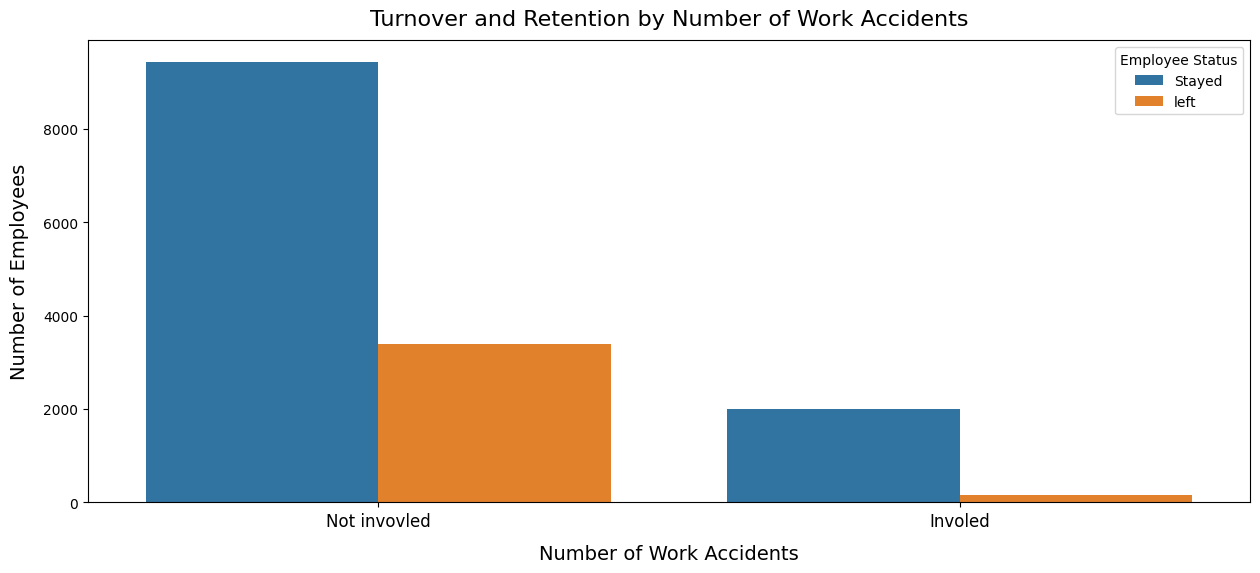

In [42]:
plt.figure(figsize=[15,6])
sns.countplot(data=df, x='Work_accident', hue='left')
plt.xticks(ticks=[0,1], labels=['Not invovled', 'Involed'], fontsize=12)
plt.title('Turnover and Retention by Number of Work Accidents', fontsize=16, y=1.015)
plt.xlabel('Number of Work Accidents', labelpad=10, fontsize=14)
plt.ylabel('Number of Employees', labelpad=10, fontsize=14)
plt.legend(title='Employee Status', labels=['Stayed', 'left'])

plt.show()

The number of employees who left after being involed in work accident are relatively small compared to those who were not involed in work accident. This suggest that work accident is not a contributing factor to employees leaving the company.


#### Are employees who are promoted more or less likely to stay in the company?

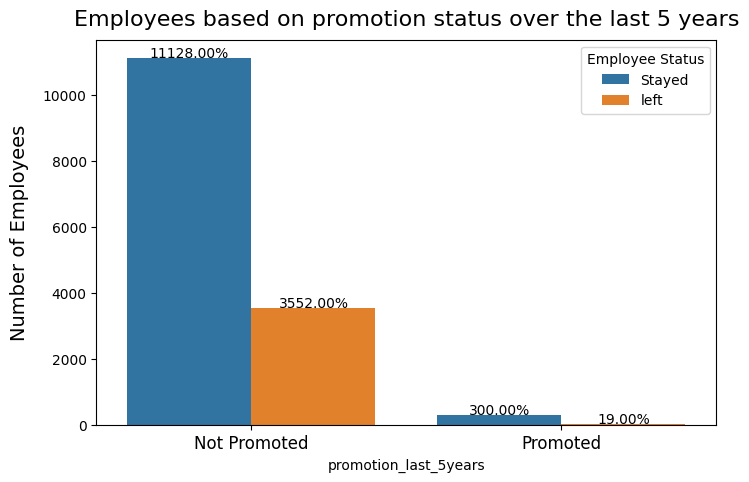

In [43]:
plt.figure(figsize=[8,5])
ax = sns.countplot(data=df, x='promotion_last_5years', hue='left')
plt.xticks(ticks=[0,1], labels=['Not Promoted', 'Promoted'], fontsize=12)
plt.title('Employees based on promotion status over the last 5 years', fontsize=16, y=1.015)
plt.ylabel('Number of Employees', labelpad=10, fontsize=14)
plt.legend(title='Employee Status', labels=['Stayed', 'left'])

# Adding data labels to the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline')

# Display the plot
plt.show()

Promotions over the last 5 years are infrequent.  Only 2% of the workforce have been promoted within the last 5 years.

Majority of employees who have recieved promotion in the last 5 years have remained in the company. The number of employees who stayed is visibly higher than the number of those who left.

This suggest that promotion may contribute positively to employee retention as those who were promoted are not leaving in large numbers as those who were not promoted.


#### How many employees who were trained in the past year decided to stay in the company?

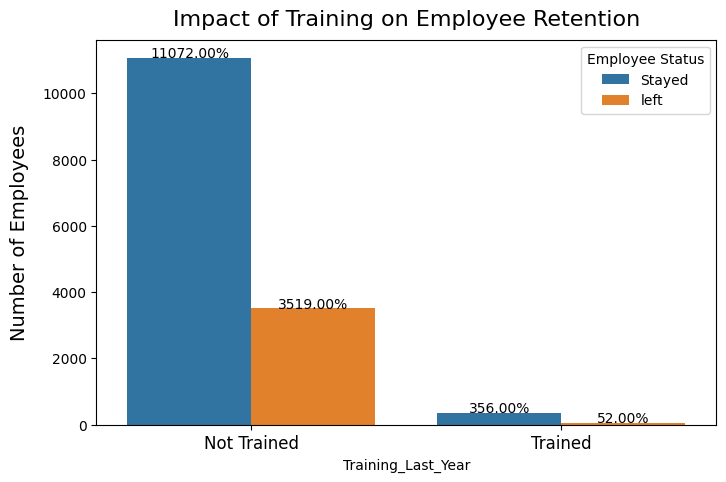

In [44]:
plt.figure(figsize=[8,5])
ax = sns.countplot(data=df, x='Training_Last_Year', hue='left')
plt.xticks(ticks=[0,1], labels=['Not Trained', 'Trained'], fontsize=12)
plt.title('Impact of Training on Employee Retention', fontsize=16, y=1.015)
plt.ylabel('Number of Employees', labelpad=10, fontsize=14)
plt.legend(title='Employee Status', labels=['Stayed', 'left'])

# Adding data labels to the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline')

# Display the plot
plt.show()

More than 97% of employees did not recieve training in the past year. Employees who have recieved training in the past year have stayed in the company.

Trainings have been very infrequent in the company. A very large percentage of untrained employees have left the company.

## Conclusion

Based on the comprehensive anlaysis of employee turnover and retention at NeoTech Corporation, the following conclusions can be drawn.

1. **Employee Satisfaction**: Overall employee satisfaction is notable, but there i a concerning number of highly dissatisfied employees. This suggest that there are systemic issues within the company that need to be addressed.
2. **Performance Evaluation**: Both high and low performing employees are leaving, indicating that performance is not a sole factor in retention. Other factors like Commute time, Salary levels and Career development play a significant role.
3. **Commute Time**: Longer commute time correlates with higher turnover, butthere are exceptions for those with extremely long commute times indicating other factors at play in retention.
4. **Salary Level**: Higher salaries are associated with better retention, while lower salaries increases the likelyhood of turnover.
5. **Promotions and Training**: Infrequent promotion and training opportunities contributes to turnover. Employees who recieve pomotion or training tend to stay, suggesting these are valued aspects of career development.
6. **Lack of Career Growth**: Employees who see few opportunities for advancement are more likely to leave.
7. **Departmental Turnover**: Sales, Techical and Support Department experience the highest turnover, particularly among dissatisfied employees which may specify areas if improvement.
8. **Work Accidents**: Work accidents do not seem to be a significant factor in employee turnover. However, quite a number of employees have been involed in work accidents.
9. **Work Load**: Both underutilization and overutilization contribute to turnover. Employees who have a balanced workload and worklife balance are more likely to stay with the company. Quite a number of employees work more tha 200 hours monthly. Employees who are overworked or over commited are more likely to leave.

## Recomendations

1. **Address Satisfaction Issues**: Implement regular assesments to identify and address the root causes of dissatisfaction such as high work loads, lack of career growth and lack of training, particularly in departments with the highest turnover.
2. **Review Work Load Management**: Ensure that employees are niether overburdened or underutilized. Ensure that employees are not working on more than 3 to 4 projects at a time to maintain engagement without causing burnout.
3. **Enhance Career Development Opportunities**: Increase the frequency o promotion and training to signal a clear career pathway for career growth, Which is likely to improve retention. Employees should be albe to see a path foor advancement within the company.
4. **Adjust Salary Structure**: Review and Adjust Salaries especially for those at the lower end,to improve satisfaction and reduce turnover.
5. **Flexible Work Arrangement**: Consider Flexible working arrangement or remote/hybrid work options to alleviate the straiinof work commute.
6. **Focus on High Performers**: Develope retention strategies specifically for high performers who show a suprising tendency to leave.
7. **Develope Specific Stratagies**: Sales, Technical and Support department require targeted strategies to improve employee satisfaction and reduce turnover as they have the highest number of leaving employees.
8. **Comprehensive Engagement Plan**: Develope a comprehensive employee engagement plan that addresses varrious aspects like work-life balance, recognition and employee wellbeing.
9. **Recognise and Reward Employees**: Employees should feel that their hard work and contributins are appreciated. this can be done bby providing regular feedback, offering recognition and rewards and creating a culture of appreciation.

By addressing this areas, NeoTech corporation can aim to reduce turnover rates, enhance employee satisfaction, and foster a work environment that supports employee retention and growth.